In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_style('whitegrid')
%matplotlib inline

### TASK 1: Data Collection & Dataset Understanding

In [4]:
# Load the data
df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# 1. Shape
print("Shape:", df.shape)

# 2. Column names
print("Columns:", df.columns.tolist())

# 3. Data types
print(df.dtypes)

# 4. First few rows
df.head()

Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Additional quick info
df.info()

# Check unique values in the target
df['Churn'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

Churn
No     5174
Yes    1869
Name: count, dtype: int64

### TASK 2: Data Cleaning & Preprocessing

In [6]:
# 1. Check missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
# 2. Fix TotalCharges (object → numeric, coerce errors)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(df.dtypes)

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object


In [8]:
# Check rows where tenure is 0 but TotalCharges is NaN
df[df['tenure'] == 0][['tenure', 'TotalCharges']].head()

,tenure,TotalCharges
488,0,NaN
753,0,NaN
936,0,NaN
1082,0,NaN
1340,0,NaN


In [9]:
# Fill NaN with 0 for tenure==0
df.loc[df['tenure'] == 0, 'TotalCharges'] = df.loc[df['tenure'] == 0, 'TotalCharges'].fillna(0)

df[df['tenure'] == 0][['tenure', 'TotalCharges']].head()

,tenure,TotalCharges
488,0,0.0
753,0,0.0
936,0,0.0
1082,0,0.0
1340,0,0.0


In [10]:
# 3. Remove duplicates
print("Duplicates before:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

Duplicates before: 0


In [11]:
# 4. Fix SeniorCitizen to categorical (yes/no)
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

In [12]:
# 5. Convert categorical columns to 'category' dtype for memory efficiency (optional)
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].astype('category')

C:\Users\User\AppData\Local\Temp\ipykernel_9620\169721649.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [13]:
# Verify
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   category
 1   gender            7043 non-null   category
 2   SeniorCitizen     7043 non-null   category
 3   Partner           7043 non-null   category
 4   Dependents        7043 non-null   category
 5   tenure            7043 non-null   int64   
 6   PhoneService      7043 non-null   category
 7   MultipleLines     7043 non-null   category
 8   InternetService   7043 non-null   category
 9   OnlineSecurity    7043 non-null   category
 10  OnlineBackup      7043 non-null   category
 11  DeviceProtection  7043 non-null   category
 12  TechSupport       7043 non-null   category
 13  StreamingTV       7043 non-null   category
 14  StreamingMovies   7043 non-null   category
 15  Contract          7043 non-null   category
 16  PaperlessBilling  7043 non-null   c

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### TASK 3: Exploratory Data Analysis (EDA)

In [14]:
# Basic statistics
df.describe(include='all')

# Churn distribution (percentage)
churn_rate = df['Churn'].value_counts(normalize=True) * 100
churn_rate

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

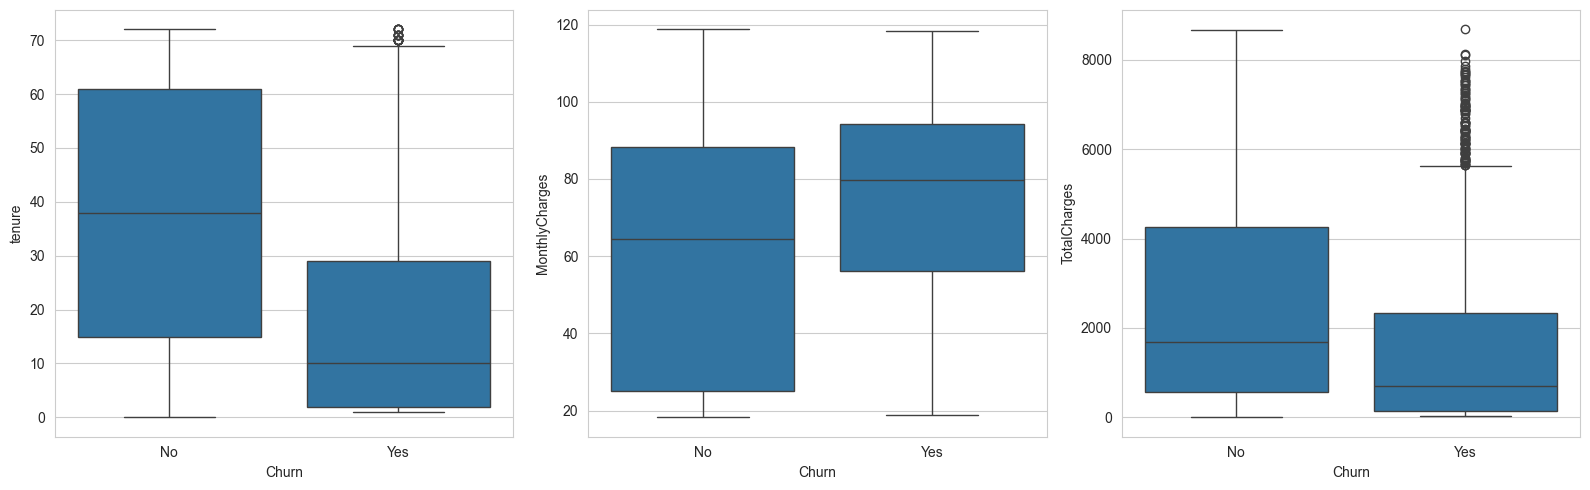

In [15]:
# Numeric vs Churn: boxplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[0])
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[1])
sns.boxplot(x='Churn', y='TotalCharges', data=df, ax=axes[2])
plt.tight_layout()
plt.show()

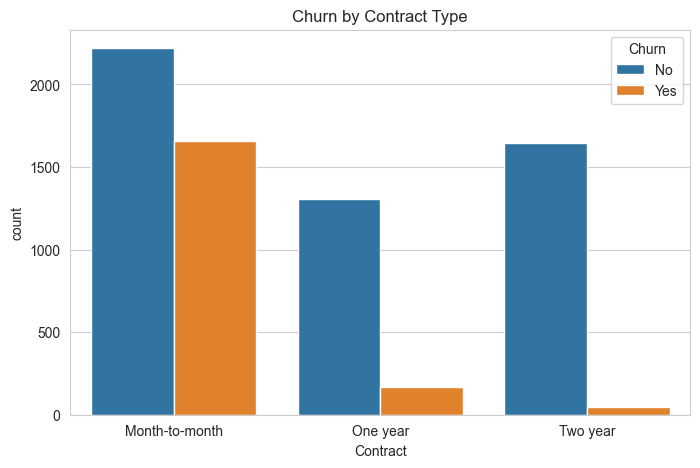

In [16]:
# Categorical vs Churn: contract type
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.show()

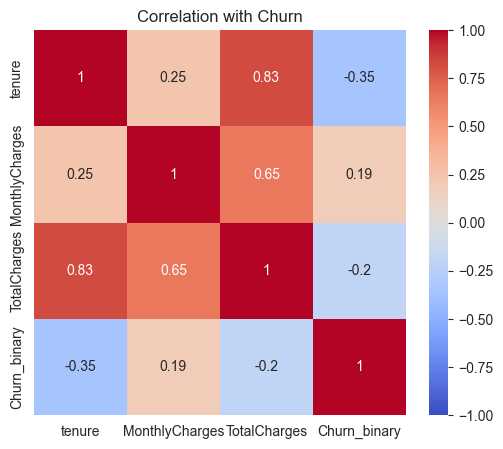

In [17]:
# Correlation heatmap (numerical features only)
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
# Encode Churn as binary 0/1 for correlation
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)
corr = df[numerical_cols + ['Churn_binary']].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation with Churn')
plt.show()

#### Insights

### TASK 4: Data Visualization

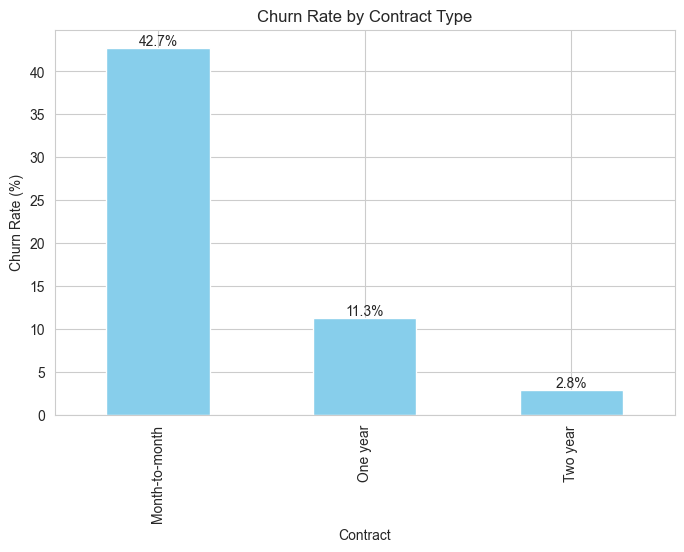

In [18]:
# 1. Churn percentage by contract type (bar plot with annotations)
contract_churn = df.groupby('Contract')['Churn_binary'].mean() * 100
ax = contract_churn.plot(kind='bar', color='skyblue', figsize=(8,5))
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Rate by Contract Type')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')
plt.show()

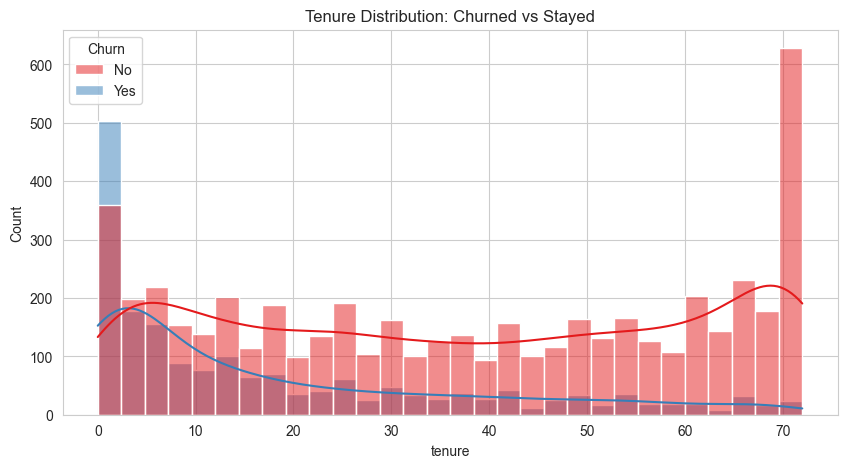

In [19]:
# 2. Tenure distribution by churn (histogram)
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True, palette='Set1')
plt.title('Tenure Distribution: Churned vs Stayed')
plt.show()

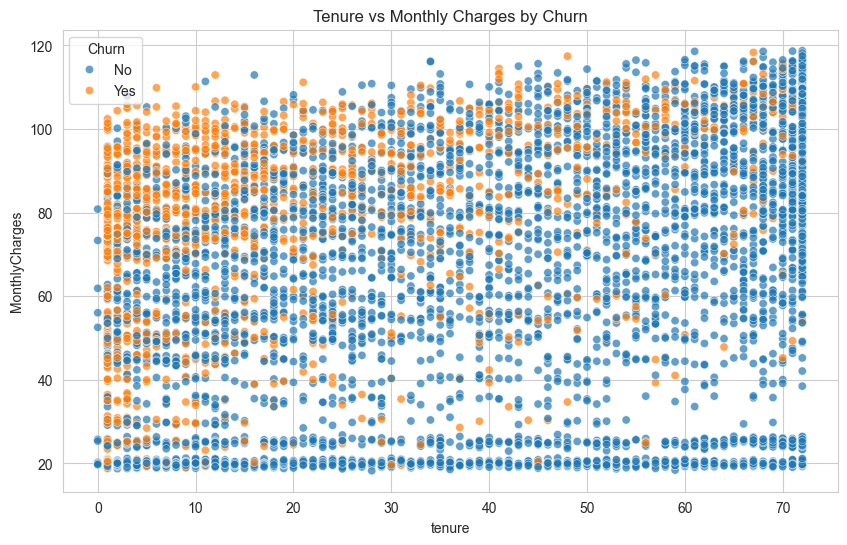

In [20]:
# 3. Monthly charges vs Total charges scatter, colored by churn
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn', alpha=0.7)
plt.title('Tenure vs Monthly Charges by Churn')
plt.show()

### TASK 5: Predictive Model


In [21]:
# # Prepare data for modeling
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# # Drop columns not needed for modeling
# df_model = df.drop(columns=['customerID', 'Churn_binary'])  # customerID usually first col, if exists

# # One-hot encode categorical variables
# df_encoded = pd.get_dummies(df_model, drop_first=True)

# # Separate features and target
# X = df_encoded.drop(columns=['Churn_Yes'])  # 'Churn_Yes' is 1 if churn else 0 (after encoding)
# y = df_encoded['Churn_Yes']

# # Train/test split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# print(f"Training size: {X_train.shape}, Test size: {X_test.shape}")

In [22]:
# # Logistic Regression
# logreg = LogisticRegression(max_iter=1000)
# logreg.fit(X_train, y_train)

# # Predictions and probabilities
# y_pred = logreg.predict(X_test)
# y_prob = logreg.predict_proba(X_test)[:, 1]

# # Evaluation
# print("Classification Report:\n", classification_report(y_test, y_pred))
# print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

# # Confusion matrix
# conf_mat = confusion_matrix(y_test, y_pred)
# sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
# plt.title('Confusion Matrix')
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.show()

In [23]:
# # Feature importance (coefficients)
# coeff_df = pd.DataFrame({
#     'Feature': X.columns,
#     'Coefficient': logreg.coef_[0]
# }).sort_values(by='Coefficient', ascending=False)

# # Top positive and negative coefficients
# print("Top 5 features increasing churn risk:")
# print(coeff_df.head())
# print("\nTop 5 features decreasing churn risk:")
# print(coeff_df.tail())

# # Plot top 10
# top10 = pd.concat([coeff_df.head(5), coeff_df.tail(5)])
# plt.figure(figsize=(10,6))
# sns.barplot(x='Coefficient', y='Feature', data=top10, palette='coolwarm')
# plt.title('Top Features Influencing Churn (Logistic Regression Coefficients)')
# plt.show()

In [24]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# # ---------------------------------------------------------
# # 1. Feature Selection & Encoding
# # ---------------------------------------------------------
# # Drop columns not needed for modeling (Identifiers & duplicate target columns)
# # errors='ignore' ensures it won't break if Churn_binary was already dropped
# df_model = df.drop(columns=['customerID', 'Churn_binary'], errors='ignore') 

# # One-hot encode categorical variables
# df_encoded = pd.get_dummies(df_model, drop_first=True)

# # Separate features (X) and target (y)
# X = df_encoded.drop(columns=['Churn_Yes'])
# y = df_encoded['Churn_Yes']

# # ---------------------------------------------------------
# # 2. Train/Test Split
# # ---------------------------------------------------------
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.3, random_state=42, stratify=y
# )

# print(f"Training size: {X_train.shape}, Test size: {X_test.shape}")

# # ---------------------------------------------------------
# # 3. Feature Scale Parity (Standardization)
# # ---------------------------------------------------------
# # Identify continuous numerical columns
# numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# scaler = StandardScaler()

# # Create copies to avoid SettingWithCopyWarning
# X_train_scaled = X_train.copy()
# X_test_scaled = X_test.copy()

# # Fit the scaler ONLY on the training data to prevent data leakage, then transform both
# X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
# X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

# # ---------------------------------------------------------
# # 4. Logistic Regression Modeling
# # ---------------------------------------------------------
# # Initialize and fit the model on the SCALED training data
# logreg = LogisticRegression(max_iter=1000, random_state=42)
# logreg.fit(X_train_scaled, y_train)

# # Predictions and probabilities
# y_pred = logreg.predict(X_test_scaled)
# y_prob = logreg.predict_proba(X_test_scaled)[:, 1]

# # ---------------------------------------------------------
# # 5. Model Evaluation & Insights
# # ---------------------------------------------------------
# print("\n--- Model Performance ---")
# print("Classification Report:\n", classification_report(y_test, y_pred))
# print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# # Extract Scaled Feature importance (coefficients)
# coeff_df = pd.DataFrame({
#     'Feature': X.columns,
#     'Coefficient': logreg.coef_[0]
# }).sort_values(by='Coefficient', ascending=False)

# print("\n--- Structural Churn Drivers (Standardized) ---")
# print("\nTop 5 features INCREASING churn risk:")
# print(coeff_df.head())

# print("\nTop 5 features DECREASING churn risk (Retention Anchors):")
# print(coeff_df.tail())

# # Optional: Plot the Confusion Matrix
# plt.figure(figsize=(6, 4))
# conf_mat = confusion_matrix(y_test, y_pred)
# sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
# plt.title('Confusion Matrix (Scaled Model)')
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.tight_layout()
# plt.show()

Train columns: 33
Test columns after alignment: 33
After SMOTE: 7244 samples, churn rate: 50.00%

RANDOM FOREST (with SMOTE + balanced)
              precision    recall  f1-score   support

       False       0.86      0.82      0.84      1552
        True       0.56      0.63      0.59       561

    accuracy                           0.77      2113
   macro avg       0.71      0.73      0.72      2113
weighted avg       0.78      0.77      0.77      2113

ROC AUC: 0.8139

XGBOOST (with SMOTE)
              precision    recall  f1-score   support

       False       0.87      0.82      0.84      1552
        True       0.56      0.65      0.60       561

    accuracy                           0.77      2113
   macro avg       0.71      0.73      0.72      2113
weighted avg       0.78      0.77      0.78      2113

ROC AUC: 0.8135

Top 10 Features (XGBoost):
                           Feature  Importance
28               Contract_Two year    0.358705
13     InternetService_Fiber optic

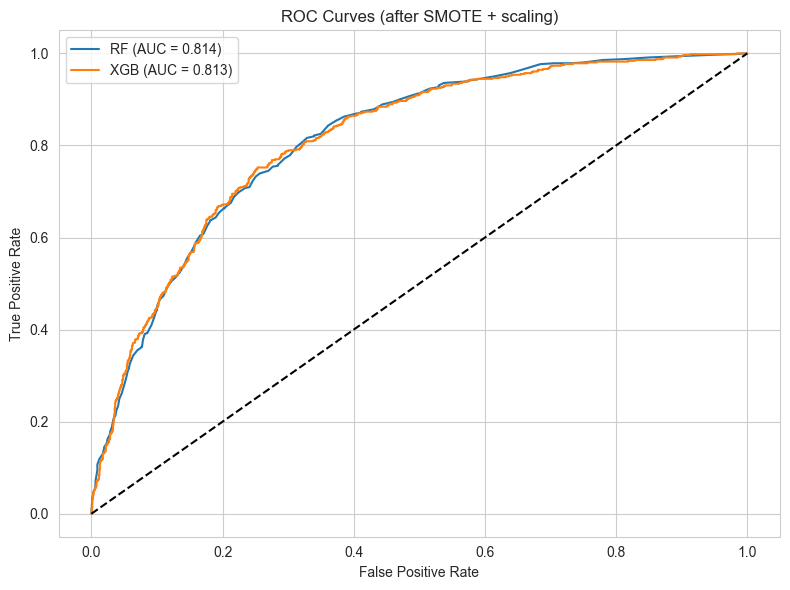

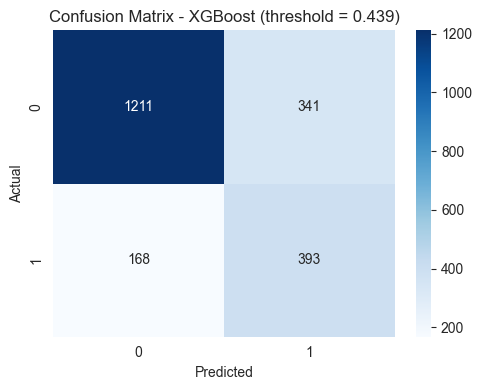


Model and scaler saved as 'churn_model.pkl' and 'scaler.pkl'


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix, precision_recall_curve, fbeta_score

# -------------------------------------------------------------
# 1. Feature engineering
# -------------------------------------------------------------
df['AvgMonthlyCharge'] = df['TotalCharges'] / (df['tenure'] + 1e-6)
df['Tenure_MonthlyCharges'] = df['tenure'] * df['MonthlyCharges']
df['Tenure_sq'] = df['tenure'] ** 2

# -------------------------------------------------------------
# 2. Encode categorical variables
# -------------------------------------------------------------
df_model = df.drop(columns=['customerID', 'Churn_binary'], errors='ignore')
df_encoded = pd.get_dummies(df_model, drop_first=True)

X = df_encoded.drop(columns=['Churn_Yes'])
y = df_encoded['Churn_Yes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# -------------------------------------------------------------
# 3. Ensure test columns match train columns
# -------------------------------------------------------------
missing_cols = set(X_train.columns) - set(X_test.columns)
for col in missing_cols:
    X_test[col] = 0
extra_cols = set(X_test.columns) - set(X_train.columns)
X_test = X_test.drop(columns=extra_cols)
X_test = X_test[X_train.columns]

print("Train columns:", X_train.shape[1])
print("Test columns after alignment:", X_test.shape[1])

# -------------------------------------------------------------
# 4. Scale numeric features
# -------------------------------------------------------------
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 
                'AvgMonthlyCharge', 'Tenure_MonthlyCharges', 'Tenure_sq']
numeric_cols = [c for c in numeric_cols if c in X_train.columns]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

# -------------------------------------------------------------
# 5. Apply SMOTE to training set
# -------------------------------------------------------------
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
print(f"After SMOTE: {X_train_resampled.shape[0]} samples, churn rate: {y_train_resampled.mean():.2%}")

# -------------------------------------------------------------
# 6. Train Random Forest (baseline)
# -------------------------------------------------------------
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_resampled, y_train_resampled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

print("\n" + "="*50)
print("RANDOM FOREST (with SMOTE + balanced)")
print("="*50)
print(classification_report(y_test, rf.predict(X_test_scaled)))
print(f"ROC AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")

# -------------------------------------------------------------
# 7. Train XGBoost (final model)
# -------------------------------------------------------------
xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb.fit(X_train_resampled, y_train_resampled)
y_proba_xgb = xgb.predict_proba(X_test_scaled)[:, 1]

print("\n" + "="*50)
print("XGBOOST (with SMOTE)")
print("="*50)
print(classification_report(y_test, xgb.predict(X_test_scaled)))
print(f"ROC AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")

# -------------------------------------------------------------
# 8. Feature importance
# -------------------------------------------------------------
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Features (XGBoost):")
print(importance_df.head(10))

# -------------------------------------------------------------
# 9. Threshold tuning for XGBoost (business goal: recall ≥ 0.7)
# -------------------------------------------------------------
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_xgb)
# Remove the last element (which corresponds to recall=0, precision=1)
prec = precisions[:-1]
rec = recalls[:-1]
thresh = thresholds

target_recall = 0.70
valid = rec >= target_recall
if np.any(valid):
    best_prec_idx = np.argmax(prec[valid])
    best_thresh = thresh[valid][best_prec_idx]
    print(f"\nOptimal threshold for recall ≥ {target_recall}: {best_thresh:.3f}")
    y_pred_opt = (y_proba_xgb >= best_thresh).astype(int)
    print(classification_report(y_test, y_pred_opt))
else:
    best_thresh = 0.5
    print(f"No threshold gives recall ≥ {target_recall}. Using default 0.5.")

# Optionally, compute F2‑optimal threshold (if you prefer)
best_f2 = 0
best_f2_thresh = 0.5
for t in np.linspace(0.1, 0.9, 50):
    y_pred_temp = (y_proba_xgb >= t).astype(int)
    f2 = fbeta_score(y_test, y_pred_temp, beta=2)
    if f2 > best_f2:
        best_f2 = f2
        best_f2_thresh = t
print(f"\nF2‑optimal threshold: {best_f2_thresh:.3f} (F2 = {best_f2:.3f})")

# -------------------------------------------------------------
# 10. ROC Curve
# -------------------------------------------------------------
plt.figure(figsize=(8,6))
for name, y_proba in [('RF', y_proba_rf), ('XGB', y_proba_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, y_proba):.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (after SMOTE + scaling)')
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 11. Confusion Matrix (at chosen threshold)
# -------------------------------------------------------------
final_pred = (y_proba_xgb >= best_thresh).astype(int)
conf_mat = confusion_matrix(y_test, final_pred)
plt.figure(figsize=(5,4))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - XGBoost (threshold = {best_thresh:.3f})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 12. Save model and scaler for deployment
# -------------------------------------------------------------
joblib.dump(xgb, 'churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("\nModel and scaler saved as 'churn_model.pkl' and 'scaler.pkl'")